In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("11-2023.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,42081627202,2023-11-01 00:52,NaN,00:00:40,NaN,Sal Berdayi
1,42082259788,2023-11-01 00:53,NaN,00:00:25,NaN,Sal Berdayi
2,42081337932,2023-11-01 00:53,NaN,00:00:12,NaN,Sal Berdayi
3,42081580883,2023-11-01 00:54,NaN,00:00:21,NaN,Sal Berdayi
4,42097263491,2023-11-01 09:13,NaN,00:01:00,NaN,Karen Parker


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13010 entries, 0 to 13009
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             13010 non-null  int64  
 1   Activity date         13010 non-null  str    
 2   Call direction        738 non-null    str    
 3   Call duration         12579 non-null  str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  13010 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.1 MB


In [9]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [11]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 13010 entries, 0 to 13009
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         13010 non-null  datetime64[us]
 1   Call direction        738 non-null    str           
 2   Call duration         12579 non-null  str           
 3   Activity assigned to  13010 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 677.0 KB


# Call Count per day

In [16]:
df2 = df1.copy()

In [18]:
df2['date'] = df2['Activity date'].dt.date

In [20]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-11-01 00:52:00,NaN,00:00:40,Sal Berdayi,2023-11-01
1,2023-11-01 00:53:00,NaN,00:00:25,Sal Berdayi,2023-11-01
2,2023-11-01 00:53:00,NaN,00:00:12,Sal Berdayi,2023-11-01
3,2023-11-01 00:54:00,NaN,00:00:21,Sal Berdayi,2023-11-01
4,2023-11-01 09:13:00,NaN,00:01:00,Karen Parker,2023-11-01


In [22]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [24]:
daily_calls.head()

,date,call_count
0,2023-11-01,626
1,2023-11-02,616
2,2023-11-03,350
3,2023-11-04,80
4,2023-11-05,104


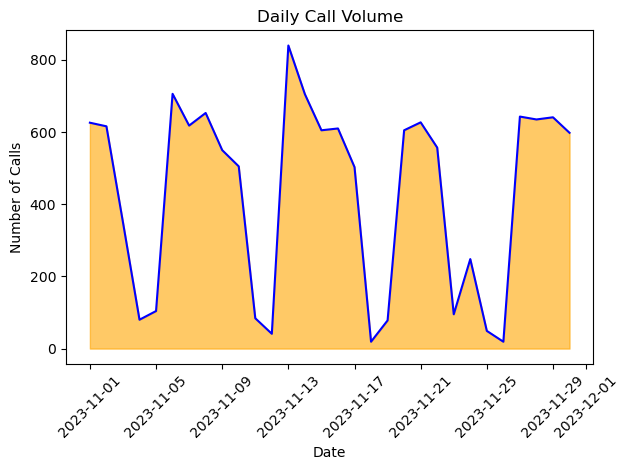

In [26]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [29]:
df1['day'] = df1['Activity date'].dt.day_name()

In [31]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-11-01 00:52:00,NaN,00:00:40,Sal Berdayi,Wednesday
1,2023-11-01 00:53:00,NaN,00:00:25,Sal Berdayi,Wednesday
2,2023-11-01 00:53:00,NaN,00:00:12,Sal Berdayi,Wednesday
3,2023-11-01 00:54:00,NaN,00:00:21,Sal Berdayi,Wednesday
4,2023-11-01 09:13:00,NaN,00:01:00,Karen Parker,Wednesday


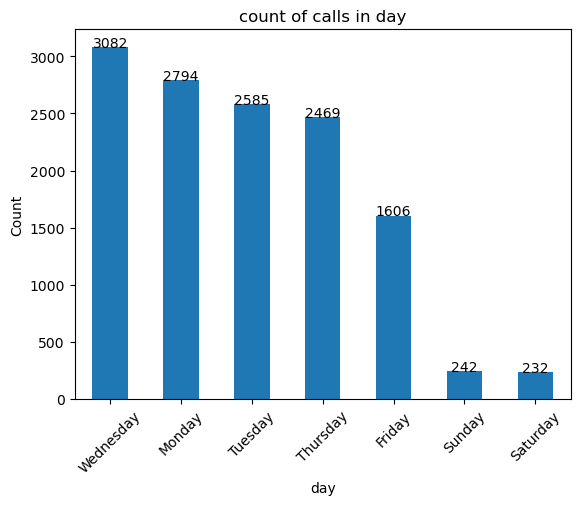

In [33]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

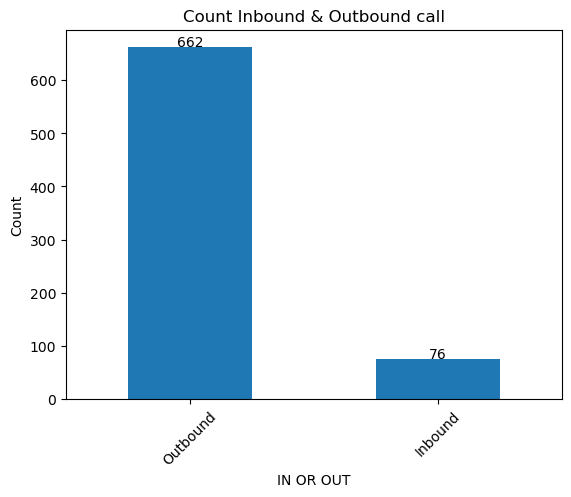

In [36]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [39]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

IndexError: index 0 is out of bounds for axis 0 with size 0

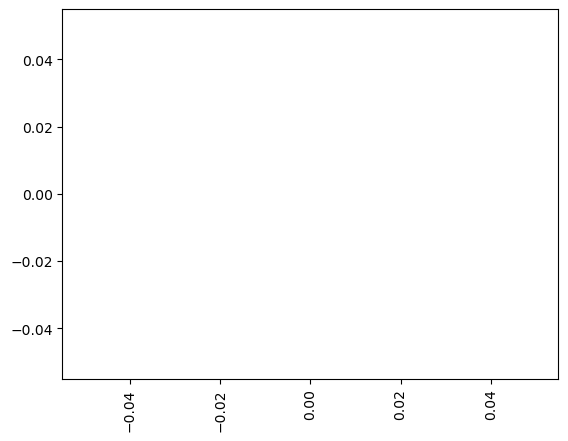

In [41]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have call direction

In [44]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
5,2023-11-01 09:26:00,Inbound,NaN,Robin Stoehr,Wednesday
7,2023-11-01 09:32:00,Inbound,NaN,Robin Stoehr,Wednesday
8,2023-11-01 09:34:00,Inbound,NaN,Robin Stoehr,Wednesday
25,2023-11-01 10:17:00,Outbound,NaN,Robin Stoehr,Wednesday
145,2023-11-01 14:10:00,Outbound,NaN,Robin Stoehr,Wednesday
...,...,...,...,...,...
12493,2023-11-30 11:46:00,Inbound,NaN,Robin Stoehr,Thursday
12534,2023-11-30 12:31:00,Outbound,NaN,Keith Antonio,Thursday
12539,2023-11-30 12:34:00,Outbound,NaN,Keith Antonio,Thursday
12734,2023-11-30 16:01:00,Outbound,NaN,Keith Antonio,Thursday


In [46]:
df4 = df1.copy()

In [48]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-11-01 00:52:00,NaN,00:00:40,Sal Berdayi,Wednesday
1,2023-11-01 00:53:00,NaN,00:00:25,Sal Berdayi,Wednesday
2,2023-11-01 00:53:00,NaN,00:00:12,Sal Berdayi,Wednesday
3,2023-11-01 00:54:00,NaN,00:00:21,Sal Berdayi,Wednesday
4,2023-11-01 09:13:00,NaN,00:01:00,Karen Parker,Wednesday


In [50]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [52]:
(df4['Call duration'] == 0).sum()

0

In [54]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [56]:
df4 = df4.dropna(subset = ['Call direction'])

In [58]:
(df4['Call duration'] == 0).sum()

188

In [60]:
df4.info()

<class 'pandas.DataFrame'>
Index: 738 entries, 5 to 12854
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         738 non-null    datetime64[us]
 1   Call direction        738 non-null    str           
 2   Call duration         738 non-null    float64       
 3   Activity assigned to  738 non-null    str           
 4   day                   738 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 54.6 KB


# Working Call Assigner

In [63]:
df1['Activity assigned to'].nunique()

21

In [65]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[        'Sal Berdayi',        'Karen Parker',        'Robin Stoehr',
      'Cameron Dudley',       'Oliver Martin',       'Pete Clements',
         'Adrian Tran',    'Colby Rintharamy',        'Louis Maciel',
        'David Valdez',    'Vladimir Suparto',      'David Banister',
         'Jinky Rance',       'Keith Antonio',        'Ray Levesque',
 'Demmie Rose Tamonan',        'Dioni Canega',    'Chrystel Manabat',
           'Terry Kim',         'Paol Guzman',       'Sam Steindorf']
Length: 21, dtype: str

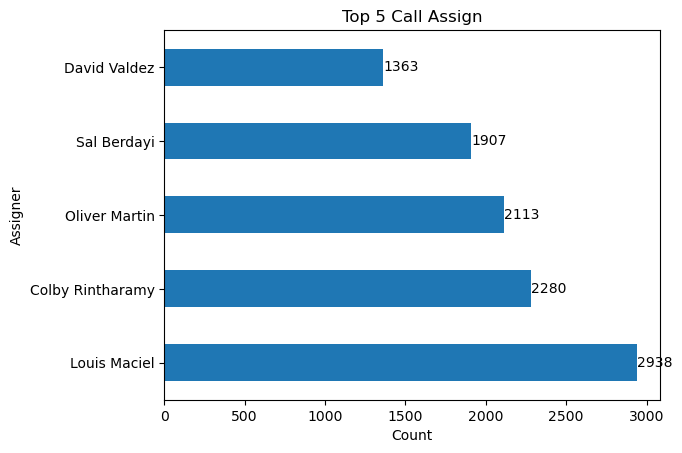

In [67]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [70]:
df4['Call duration'].max()

73.3

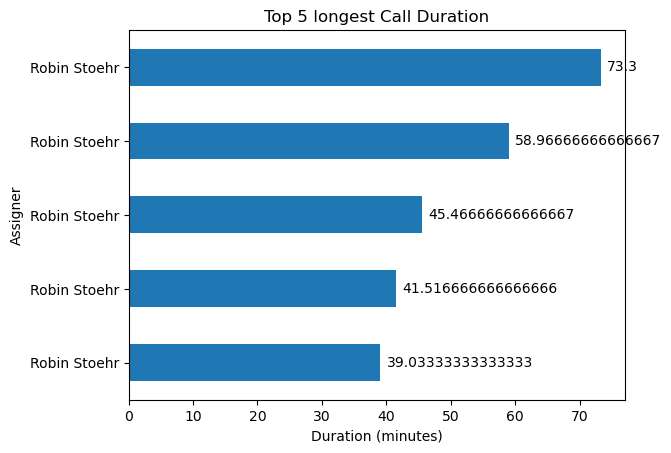

In [72]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [76]:
df3 = df1.copy()

In [78]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [80]:
df3['day'].unique()

<ArrowStringArray>
['Wednesday', 'Thursday', 'Friday', 'Monday', 'Tuesday']
Length: 5, dtype: str

In [82]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

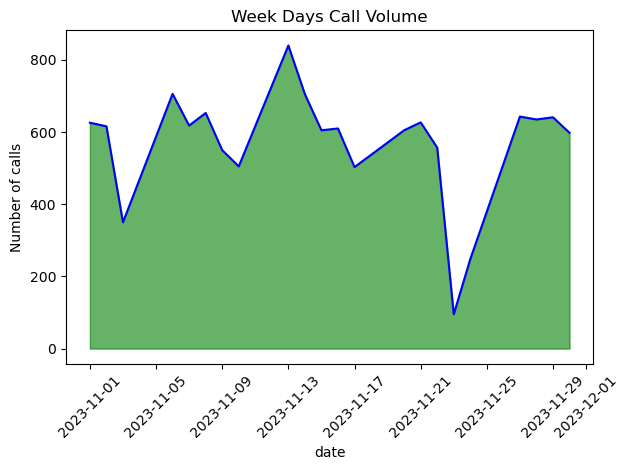

In [84]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [87]:
df5=df4.copy()

In [89]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [91]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
1739,2023-11-05 12:11:00,Outbound,0.000000,Keith Antonio,Sunday
1762,2023-11-05 18:56:00,Outbound,0.000000,Keith Antonio,Sunday
1767,2023-11-05 19:03:00,Outbound,0.000000,Keith Antonio,Sunday
8241,2023-11-19 14:01:00,Outbound,13.366667,Keith Antonio,Sunday
8253,2023-11-19 14:15:00,Outbound,0.000000,Keith Antonio,Sunday


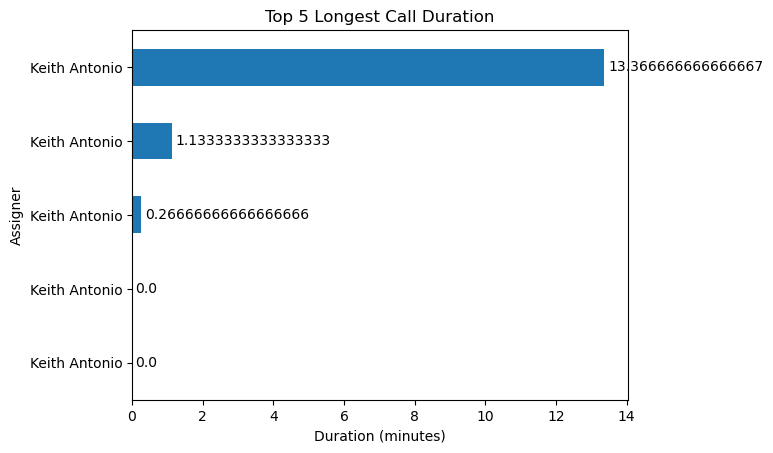

In [93]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

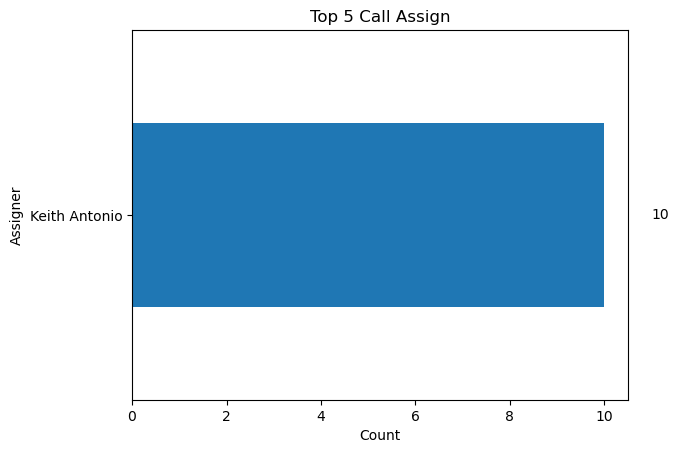

In [96]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [99]:
df4["Call duration"].mean()

3.33046522131888

In [101]:
df4["Call duration"].median()

0.9666666666666667

# Top 5 Peak Call date

In [104]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [106]:
top5 = daily_calls.sort_values(ascending=False).head(5)

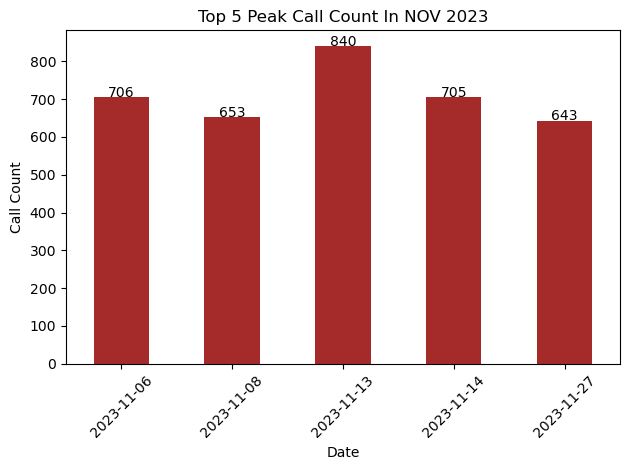

In [110]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In NOV 2023")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()